# Import Library

In [12]:
import numpy as np
from numpy import where
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, SVMSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, NearMiss, TomekLinks
from sklearn.neural_network import MLPClassifier
from imblearn.pipeline import Pipeline
from sklearn import clone
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score


# Soal

### **Ketentuan:**

1. Dokumen template lab dengan format .ipynb dan dataset (jika dibutuhkan) telah disediakan.
2. Jalankan kode pada dokumen .ipynb dan perhatikan dengan saksama apa yang potongan kode tersebut lakukan beserta dengan keluarannya. Jawablah **pertanyaan** yang disisipkan pada potongan program yang diberikan.
3. Dokumen Jupyter Notebook yang telah dilengkapi dengan jawaban dikumpulkan dalam sebuah repositori Git (misalnya, di GitHub atau GitLab) dan kirimkan tautannya kepada kami.
4. Sebelum di kumpulkan, kode **WAJIB** dijalankan.

## Deskripsi Dataset

Dataset yang akan dipakai pada soal ini adalah dataset [Bank Customer Churn](https://www.kaggle.com/datasets/radheshyamkollipara/bank-customer-churn) dengan sedikit modifikasi. Silahkan klik link tersebut untuk mengetahui penjelasan fitur-fiturnya.

Target variable pada dataset ini adalah `Exited`. Jumlah customer yang tidak meninggalkan bank (`Exited=0`) adalah 7962, sedangkan jumlah customer yang meninggalkan bank (`Exited=1`) adalah 159. Ini membuat dataset menjadi imbalance dan anda akan menangani kasus imbalance data tersebut.

In [13]:
df=pd.read_csv('Customer-Churn-Records-v2.csv')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8121 entries, 0 to 8120
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         8121 non-null   int64  
 1   Geography           8121 non-null   object 
 2   Gender              8121 non-null   object 
 3   Age                 8121 non-null   int64  
 4   Tenure              8121 non-null   int64  
 5   Balance             8121 non-null   float64
 6   NumOfProducts       8121 non-null   int64  
 7   HasCrCard           8121 non-null   int64  
 8   IsActiveMember      8121 non-null   int64  
 9   EstimatedSalary     8121 non-null   float64
 10  Exited              8121 non-null   int64  
 11  Complain            8121 non-null   int64  
 12  Satisfaction Score  8121 non-null   int64  
 13  Card Type           8121 non-null   object 
 14  Point Earned        8121 non-null   int64  
dtypes: float64(2), int64(10), object(3)
memory usage: 951.8

In [15]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,757,Germany,Female,34,9,101861.36,2,0,0,187011.96,0,0,5,PLATINUM,903
1,644,France,Male,33,8,0.00,2,1,1,155294.17,0,0,5,SILVER,813
2,655,Spain,Female,56,5,0.00,2,1,1,41782.70,0,0,2,PLATINUM,979
3,710,Spain,Female,36,8,0.00,2,0,0,83206.19,0,0,3,SILVER,636
4,684,Spain,Female,31,8,0.00,2,1,0,188637.05,0,0,4,SILVER,515


In [16]:
df['Exited'].value_counts()

Exited
0    7962
1     159
Name: count, dtype: int64

## 1. Imbalanced dataset

a) Buatlah sebuah dataset baru yang terdiri dari kolom `EstimatedSalary` dan kolom `Balance` sebagai fitur-fiturnya (X), dan kolom `Exited` sebagai target (y).

In [17]:
#Jawaban 1a
dat_new = df[['EstimatedSalary', "Balance", 'Exited']]

b) Hitung jumlah masing-masing target (Hint: Counter).

In [18]:
# Jawaban 1b
jumlah_masing_masing_trgt = Counter(dat_new['Exited'])
print('Jawaban:',jumlah_masing_masing_trgt)

# Jawaban 1b lain
jumlah_masing_masing_trgt2 = dat_new['Exited'].value_counts()
print('Jawaban Lain:', jumlah_masing_masing_trgt2)

Jawaban: Counter({0: 7962, 1: 159})
Jawaban Lain: Exited
0    7962
1     159
Name: count, dtype: int64


c) Visualisasikan dataset pada soal (1a) dengan scatter plot. Berikan warna yang berbeda untuk setiap kelasnya

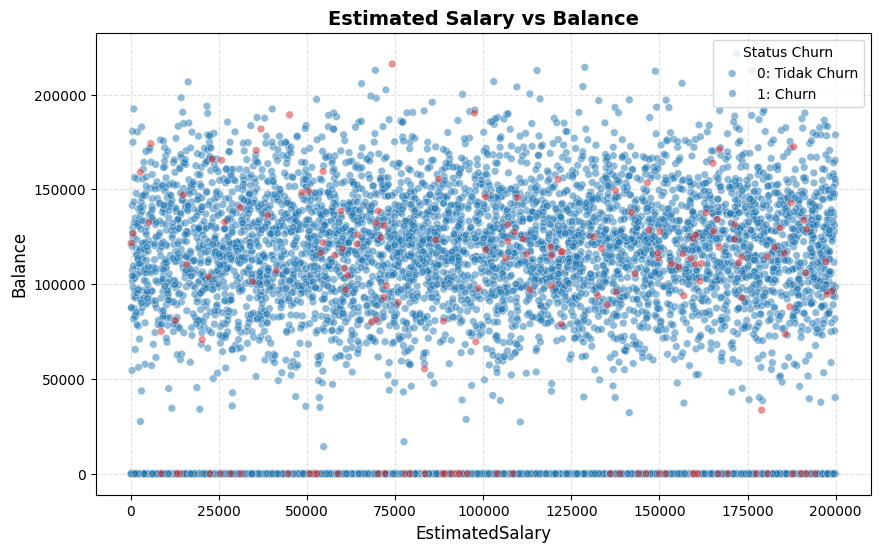

In [19]:
import seaborn as sns # saya menggunakan seabord untuk membuat ScatterPlot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=dat_new, 
    x='EstimatedSalary', 
    y='Balance', 
    hue='Exited', 
    palette={0: '#1f77b4', 1: '#d62728'}, 
    alpha=0.5,
    s=30       
)# saya menggunakan warna biru dan merah untuk yang stay dan yang keluar
plt.title('Estimated Salary vs Balance', fontsize=14, fontweight='bold')
plt.xlabel('EstimatedSalary', fontsize=12)
plt.ylabel('Balance', fontsize=12)
plt.legend(title='Status Churn', labels=['0: Tidak Churn', '1: Churn'])
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

d) Lengkapilah fungsi di bawah ini untuk melakukan oversampling pada setiap fold ketika melakukan cross validation pada suatu model menggunakan StratifiedKFold dengan k=5, shuffle=True, dan random_state=42. Tampilkan juga rata-rata skor accuracy, f1 macro, precision macro, dan recall macro.

Jalankan fungsi tersebut dengan menggunakan:
- DecisionTreeClassifier, dengan random_state=42
- Teknik oversampling RandomOversampler, dengan random_state=42
- X dan y yang didefinisikan pada soal (1a)

*(Pastikan validation test dataset tidak terganggu oleh penambahan data - data sintetis.)*

In [20]:
def train_and_evaluate_with_oversampling(model, X, y, resample_method):
    # TODO: Gunakan StratifiedK-fold biasa
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # TODO: Simpan hasil skor metrik setiap iterasi pada sebuah list
    list_accuracy = []
    list_f1 = []
    list_precision = []
    list_recall = []

    # Iterasi untuk membagi fold mana yang menjadi training dan validation test dataset
    for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
        # Gunakan .iloc jika X dan y adalah Pandas DataFrame/Series, 
        # Jika X dan y sudah berupa numpy array, hilangkan .iloc
        X_train = X.iloc[train_index] if hasattr(X, 'iloc') else X[train_index]
        y_train = y.iloc[train_index] if hasattr(y, 'iloc') else y[train_index]
        X_test = X.iloc[test_index] if hasattr(X, 'iloc') else X[test_index]
        y_test = y.iloc[test_index] if hasattr(y, 'iloc') else y[test_index]

        # TODO: Lakukan fit resample dari menggunakan variabel resample_method
        X_train_sampled, y_train_sampled = resample_method.fit_resample(X_train, y_train)

        model_clone = clone(model) # Cloning model

        # TODO: Lakukan fitting model dari hasil clone model dengan X dan y dataset yang sudah diresample
        model_clone.fit(X_train_sampled, y_train_sampled)

        # TODO: Prediksi kelas kategori menggunakan model yang telah dilatih
        y_pred = model_clone.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="macro")
        precision = precision_score(y_test, y_pred, average="macro")
        recall = recall_score(y_test, y_pred, average="macro")

        # TODO: Tambahkan hasil skor metrik ke dalam list yang bersesuaian
        list_accuracy.append(accuracy)
        list_f1.append(f1)
        list_precision.append(precision)
        list_recall.append(recall)

    # TODO: Hitung dan tampilkan mean dari setiap list skor metrik
    print("Mean scores across all folds:")
    print(f'Mean Accuracy: {np.mean(list_accuracy)}')
    print(f'Mean F1-score (macro): {np.mean(list_f1)}')
    print(f'Mean Precision (macro): {np.mean(list_precision)}')
    print(f'Mean Recall (macro): {np.mean(list_recall)}')

X = dat_new[['EstimatedSalary', "Balance"]]
y = dat_new['Exited']
# Inisialisasi Model sesuai instruksi
dt_model = DecisionTreeClassifier(random_state=42)

# Inisialisasi metode Oversampling sesuai instruksi
ros = RandomOverSampler(random_state=42)

# Jalankan fungsinya (Pastikan variabel X dan y mu sudah terdefinisi dari soal 1a)
train_and_evaluate_with_oversampling(model=dt_model, X=X, y=y, resample_method=ros)

Mean scores across all folds:
Mean Accuracy: 0.9635509662751043
Mean F1-score (macro): 0.4976120916265085
Mean Precision (macro): 0.497570140331623
Mean Recall (macro): 0.49772234982701613


jawaban) saya memisahkan antara data validasi/test dengan data train nya

e) Jalankan kode di bawah ini. Apakah terdapat perbedaan skor dengan yang ada pada soal (1d)? Jika berbeda, mengapa hal tersebut bisa terjadi, dan approach manakah yang lebih tepat untuk dilakukan (approach (1d) atau (1e))?

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_oversampled, y_oversampled = RandomOverSampler(random_state=42).fit_resample(X, y)

scoring = ['accuracy','f1_macro', 'precision_macro', 'recall_macro']
for i in range(len(scoring)):
  score = cross_val_score(DecisionTreeClassifier(random_state=42), X_oversampled, y_oversampled, scoring=scoring[i], cv=cv, n_jobs=-1)
  print(f"{scoring[i]} score: {np.mean(score)}")

accuracy score: 0.9889476030071865
f1_macro score: 0.9889460502661436
precision_macro score: 0.9891971322065523
recall_macro score: 0.9889470500651404


Jawaban untuk 1e: Score nya sangat berbeda antara soal 1d, score 1e cukup tinggi untuk f1 macro nya dan untuk score 1d cukup kecil. Kenapa itu bisa terjadi, karena di soal 1e terdapat data leakage di validationnya. dikarenakan data 1e saat mau oversampling, semua data dilakukan oversampling tanpa spliting atau di bagi terlebih dahulu. Untuk data 1d, datanya di splitting terlebih dahulu sebelum masuk ke oversampling. untuk model mana yang terbaik, tidak ada model yang terbaik, untuk model 1d dia tidak bisa memahami konteks dari data label = 1 karena yang di train hanya data oversampling dari data itu sendiri, untuk model 1e karena oversampling data secara bersamaan, model mempelajari hanya di lingkar itu saja dan akurasi hanya mendeteksi hasil dari deteksi yang di training sebelumnya.

f) Mengapa StratifiedKFold umumnya lebih sering digunakan dalam kasus Imbalanced dataset dibandingkan KFold biasa? Jelaskan serta berikan sumber referensi anda.

Karena metode StratifiedKFold mempertahankan rasio atau proporsi dari jumlah atau distribusi kelas nya. sementara Kfold hanya membagi data murni secara acak. Refrensi ada di Dokumentasi Resmi Scikit-Learn.

## 2. Oversampling

a) Terapkan metode oversampling yang paling sesuai menurut anda dan bisa diterapkan dengan dataset soal (1a). Visualisasikan scatter plot hasil resampling datasetnya

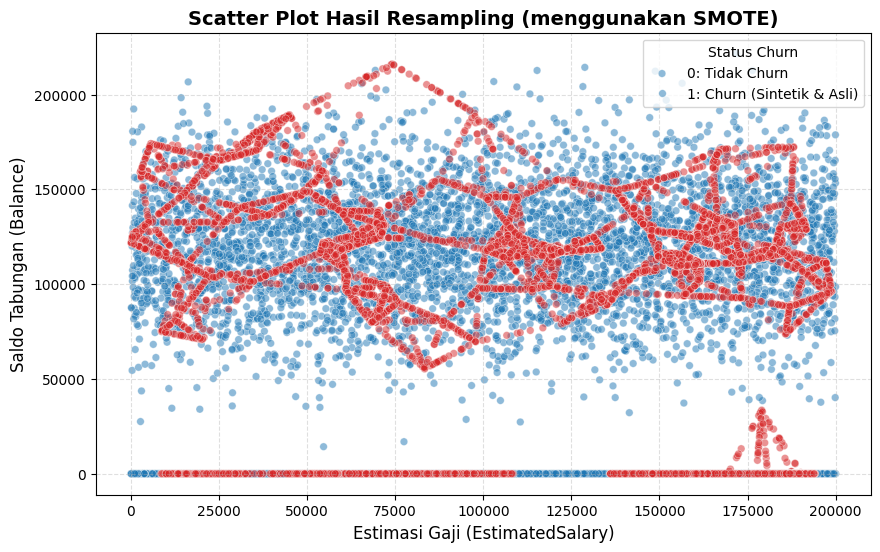

Jumlah data SEBELUM oversampling:
Exited
0    7962
1     159
Name: count, dtype: int64

Jumlah data SESUDAH oversampling:
Exited
0    7962
1    7962
Name: count, dtype: int64


In [22]:
# 1. Inisialisasi dan terapkan metode oversampling SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Gabungkan kembali X_resampled dan y_resampled jadi dataframe agar mudah di-plot
df_resampled = pd.DataFrame(X_resampled, columns=['EstimatedSalary', 'Balance'])
df_resampled['Exited'] = y_resampled

# --- Mulai Visualisasi ---

# 2. Visualisasi Scatter Plot setelah Oversampling
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_resampled, 
    x='EstimatedSalary', 
    y='Balance', 
    hue='Exited', 
    palette={0: '#1f77b4', 1: '#d62728'}, # Biru untuk 0, Merah untuk 1
    alpha=0.5, 
    s=30
)

# Menambahkan judul dan label sumbu
plt.title('Scatter Plot Hasil Resampling (menggunakan SMOTE)', fontsize=14, fontweight='bold')
plt.xlabel('Estimasi Gaji (EstimatedSalary)', fontsize=12)
plt.ylabel('Saldo Tabungan (Balance)', fontsize=12)

# Mengatur legenda
plt.legend(title='Status Churn', labels=['0: Tidak Churn', '1: Churn (Sintetik & Asli)'])

# Menampilkan garis bantu
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# (Opsional) Tampilkan perbandingan jumlah data untuk memastikan berhasil
print("Jumlah data SEBELUM oversampling:")
print(y.value_counts())
print("\nJumlah data SESUDAH oversampling:")
print(y_resampled.value_counts())

b) Terapkan metode oversampling yang lain yang berbeda dengan metode pada soal (2a). Visualisasikan scatter plot hasil resampling datasetnya

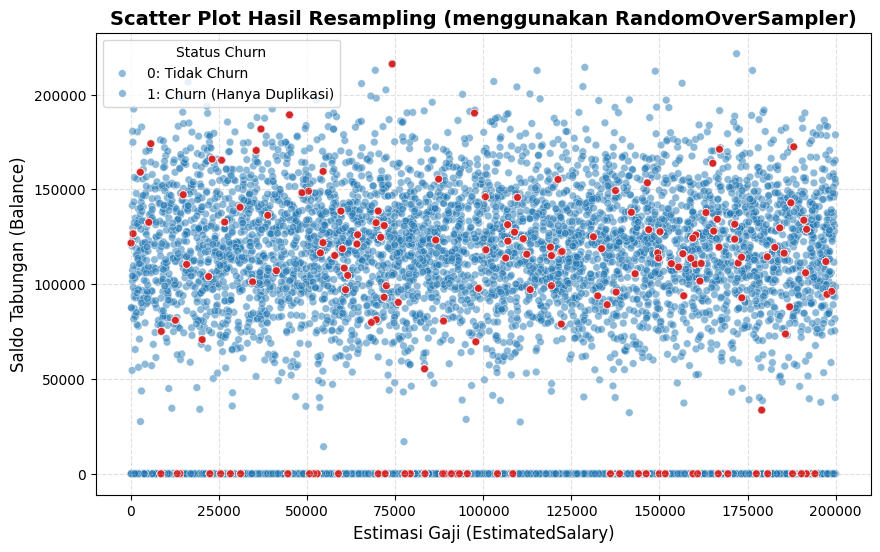

In [23]:
# 1. Inisialisasi dan terapkan metode RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled_ros, y_resampled_ros = ros.fit_resample(X, y)

# Gabungkan kembali jadi dataframe untuk plotting
df_resampled_ros = pd.DataFrame(X_resampled_ros, columns=['EstimatedSalary', 'Balance'])
df_resampled_ros['Exited'] = y_resampled_ros

# 2. Visualisasi Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_resampled_ros, 
    x='EstimatedSalary', 
    y='Balance', 
    hue='Exited', 
    palette={0: '#1f77b4', 1: '#d62728'}, 
    alpha=0.5, 
    s=30
)

# Menambahkan judul dan label sumbu
plt.title('Scatter Plot Hasil Resampling (menggunakan RandomOverSampler)', fontsize=14, fontweight='bold')
plt.xlabel('Estimasi Gaji (EstimatedSalary)', fontsize=12)
plt.ylabel('Saldo Tabungan (Balance)', fontsize=12)

# Mengatur legenda
plt.legend(title='Status Churn', labels=['0: Tidak Churn', '1: Churn (Hanya Duplikasi)'])

plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

c) Adakah perbedaan yang Anda temukan dari pengamatan terhadap data hasil kedua metode oversampling yang Anda pilih? Jika ada, jelaskan mengapa perbedaan tersebut bisa terjadi! Sertakan sumber referensi anda

Jawaban 2c: ada perbedaan antara 2a dan 2b. 2a saya menggunakan menggunakan SMOTE dan 2b saya menggunakan Oversampling. 2a sangan bervariatif untuk sebaran kelas 1 karena menggunakan metode SMOTE, SMOTE sendiri membuat data baru atau membuat data sintetik dengan menggunakan K-Nearest Neighbour, jadi data yang di hasilkan cukup bervariatif. Untuk 2b saya menggunakan Oversampling data sampling tetap sama karena oversampling hanya mengcopy data yang sudah ada. Refrensi di journal Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic Minority Over-sampling Technique. Journal of Artificial Intelligence Research, 16, 321-357. dan journal Lemaître, G., Nogueira, F., & Aridas, C. K. (2017). Imbalanced-learn: A Python Toolbox to Tackle the Curse of Imbalanced Datasets in Machine Learning. Journal of Machine Learning Research, 18(17), 1-5.

d) Lakukan cross validation menggunakan StratifiedKFold dengan k=5 pada 2 buah model Decision Tree yang berbeda dengan ketentuan berikut:
- Model pertama menggunakan metode oversampling yang dipakai pada (2a)
- Model kedua menggunakan metode oversampling yang dipakai pada (2b)
- Metrik utama yang digunakan adalah f1 macro.
- Oversampling dilakukan pada setiap fold cross validation

Petunjuk: Anda bisa menggunakan cara 1d untuk menjawab soal ini.

*(Pastikan validation test dataset tidak terganggu oleh penambahan data - data sintetis.)*

In [24]:
dt_model = DecisionTreeClassifier(random_state=42)

smt = SMOTE(random_state=42)
train_and_evaluate_with_oversampling(model=dt_model, X=X, y=y, resample_method=smt)

Mean scores across all folds:
Mean Accuracy: 0.7194924592648732
Mean F1-score (macro): 0.4388088244142233
Mean Precision (macro): 0.5020141611930754
Mean Recall (macro): 0.5208467622369588


In [25]:
dt_model = DecisionTreeClassifier(random_state=42)
ros = RandomOverSampler(random_state=42)
train_and_evaluate_with_oversampling(model=dt_model, X=X, y=y, resample_method=ros)

Mean scores across all folds:
Mean Accuracy: 0.9635509662751043
Mean F1-score (macro): 0.4976120916265085
Mean Precision (macro): 0.497570140331623
Mean Recall (macro): 0.49772234982701613


e) Metode manakah yang memberikan skor F1 makro tertinggi? Jelaskan mengapa hal tersebut bisa terjadi.

Berdasarkan hasil dari kedua model tersebut. yang memiliki F1 Score tertinggi adalah Randomoversampling, Decision tree terlalu mudah menghafal RandomOversampling. dikarenakan RandomOversampling itu menduplikasi data minoritas secara identik. Untuk model yang menggunakan SMOTE kenapa menurun, model kesusahan belajar karena data minoritas tumpang tindih dengan data mayoritas, jadi model bersusah payah untuk belajar.

## 3. Undersampling

a) Terapkan metode undersampling yang paling sesuai menurut anda dan bisa diterapkan dengan dataset soal (1a). Visualisasikan scatter plot hasil resampling datasetnya

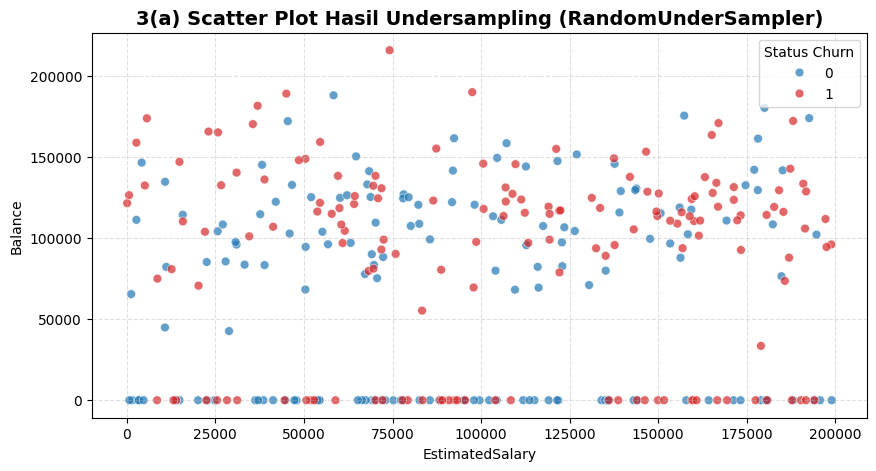

In [26]:
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)

df_rus = pd.DataFrame(X_rus, columns=['EstimatedSalary', 'Balance'])
df_rus['Exited'] = y_rus

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_rus, x='EstimatedSalary', y='Balance', hue='Exited', 
                palette={0: '#1f77b4', 1: '#d62728'}, alpha=0.7, s=40)
plt.title('3(a) Scatter Plot Hasil Undersampling (RandomUnderSampler)', fontsize=14, fontweight='bold')
plt.legend(title='Status Churn')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


b) Terapkan metode undersampling lain yang berbeda dengan metode pada soal (3a). Visualisasikan scatter plot hasil resampling datasetnya

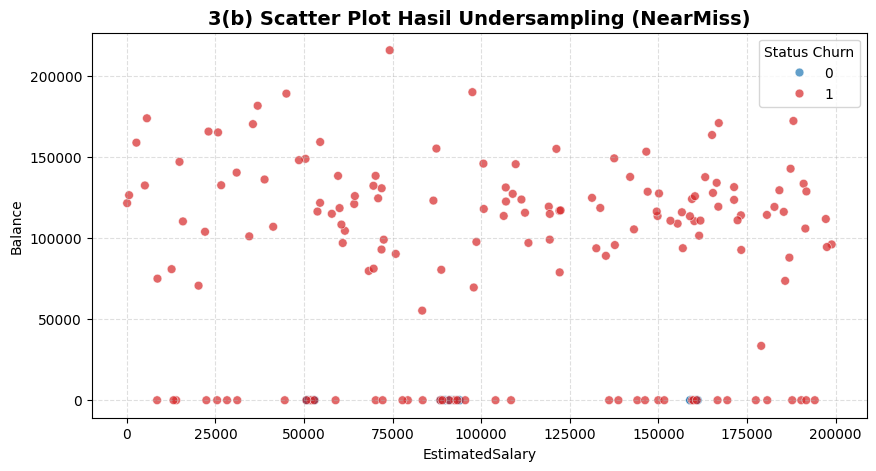

In [27]:
nm = NearMiss(version=1)
X_nm, y_nm = nm.fit_resample(X, y)

df_nm = pd.DataFrame(X_nm, columns=['EstimatedSalary', 'Balance'])
df_nm['Exited'] = y_nm

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_nm, x='EstimatedSalary', y='Balance', hue='Exited', 
                palette={0: '#1f77b4', 1: '#d62728'}, alpha=0.7, s=40)
plt.title('3(b) Scatter Plot Hasil Undersampling (NearMiss)', fontsize=14, fontweight='bold')
plt.legend(title='Status Churn')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

c) Berdasarkan visualisasi scatter plot kedua dataset hasil resampling pada soal (3a) dan (3b) yang Anda pilih, apa perbedaan yang terlihat? Jelaskan juga mengapa perbedaan tersebut bisa terjadi! Jangan lupa sertakan sumber referensi anda

pada visualisasi 3a yang biru cukup sama dengan merah karena, metode RandomUnderSampling menghapus atau menghilangkan kelas mayoritas secara acak. berbeda dengan Nearmiss, nearmiss melakukan undersampling dengan cara menghapus kelas mayoritas dengan acuan kelas minoritas terdekat(KNN). Refrensi bisa di lihat di Mani, I., & Zhang, I. (2003). kNN approach to unbalanced data distributions: a case study involving information extraction. In Proceedings of workshop on learning from imbalanced datasets (Vol. 126). dan Lemaître, G., Nogueira, F., & Aridas, C. K. (2017). Imbalanced-learn: A Python Toolbox to Tackle the Curse of Imbalanced Datasets in Machine Learning. Journal of Machine Learning Research, 18(17), 1-5.

d) Lakukan cross validation menggunakan StratifiedKFold dengan k=5 pada 2 buah model Decision Tree yang berbeda dengan ketentuan berikut:
- Model pertama menerima dataset pada soal (3a)
- Model kedua menerima dataset pada soal (3b)
- Metrik utama yang digunakan adalah f1 macro.

In [28]:
dt_model = DecisionTreeClassifier(random_state=42)

RUS = RandomUnderSampler(random_state=42)
train_and_evaluate_with_oversampling(model=dt_model, X=X, y=y, resample_method=RUS)

Mean scores across all folds:
Mean Accuracy: 0.4987067828723001
Mean F1-score (macro): 0.3500189857955057
Mean Precision (macro): 0.5007765595128328
Mean Recall (macro): 0.5103098431249661


In [29]:
nm = NearMiss(version=1)
dt_model = DecisionTreeClassifier(random_state=42)
train_and_evaluate_with_oversampling(model=dt_model, X=X, y=y, resample_method=nm)

Mean scores across all folds:
Mean Accuracy: 0.06095460401667298
Mean F1-score (macro): 0.06035484672218348
Mean Precision (macro): 0.5011109151499873
Mean Recall (macro): 0.5026262035197757


e) Metode manakah yang memberikan skor F1 makro tertinggi? Jelaskan mengapa hal tersebut bisa terjadi.

Untuk F1-Score macro tertinggi adalah model 1 yang menggunakan RangdomUndersampling. Mengapa lebih tinggi dari model yang kedua, di karena kan RandomUndersampling hanya menghilangkan data secara acak jadi nilai nilai dari kelas mayoritas masih bervariasi. dan untuk model 2 yang menggunakan Nearmiss banyak kehilangan nilai atau data yang bervariasi di karenakan data hanya seputar minoritas

## 4. Cost-Sensitive Learning

a) Buatlah beberapa model decision tree dengan random_state=42 yang menerima dataset soal (1a) dan dengan weight yang berbeda, yaiu:
- tanpa weights
- weights = {0: 1, 1: 2}
- weights = {0: 1, 1: 99}

Lakukan train_test_split dengan ketentuan berikut:
- menggunakan X dan y dari soal (1a)
- stratify=y
- random_state=42
- test_size=0.2

Kemudian, lakukan fit predict pada model dengan weights yang berbeda, kemudian tampilkan skor f1 macro dan juga confusion matrix untuk masing-masing model DT dengan weights yang berbeda tersebut. Berikan label pada Confusion matrix nya

Model Tanpa Weights - F1 Macro Score: 0.4906
Model Weights = {0: 1, 1: 2} - F1 Macro Score: 0.4901
Model Weights = {0: 1, 1: 99} - F1 Macro Score: 0.4895


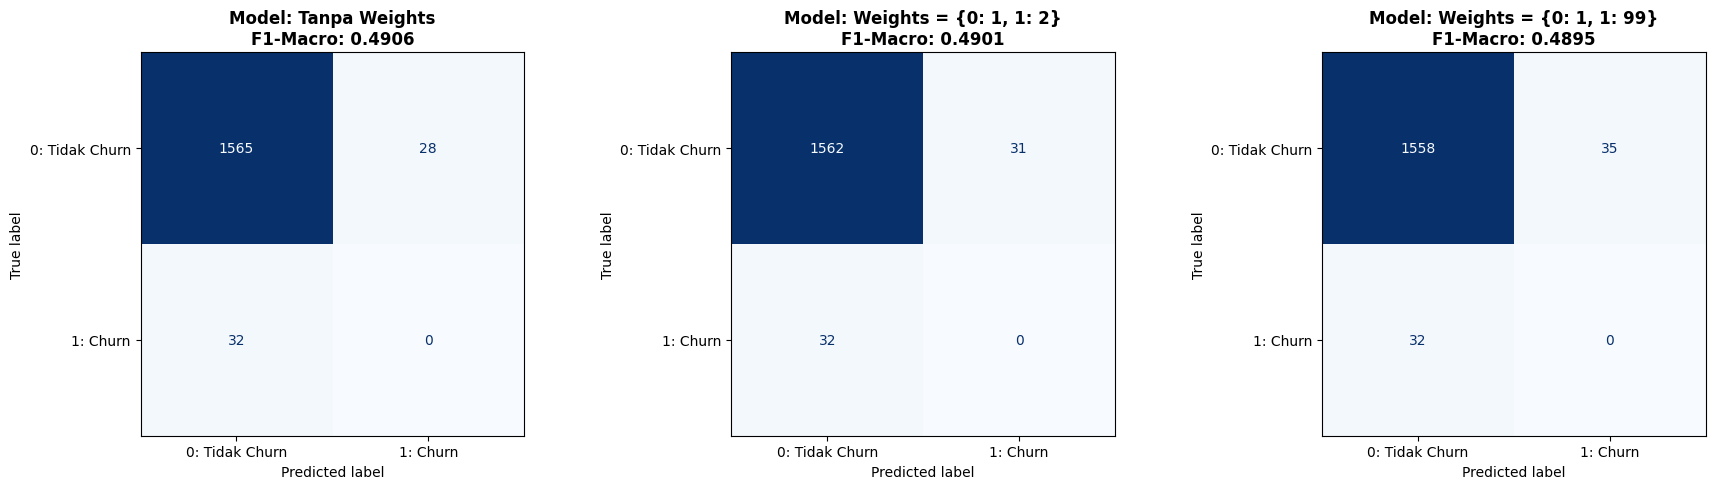

In [30]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 2. Definisikan daftar weights dan nama model untuk iterasi
weights_list = [None, {0: 1, 1: 2}, {0: 1, 1: 99}]
model_names = ['Tanpa Weights', 'Weights = {0: 1, 1: 2}', 'Weights = {0: 1, 1: 99}']

# Siapkan canvas untuk plotting 3 Confusion Matrix berjejer
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3. Iterasi untuk fit, predict, skor, dan plotting
for i, weight in enumerate(weights_list):
    # Inisialisasi model dengan weight yang berbeda
    dt_model = DecisionTreeClassifier(random_state=42, class_weight=weight)
    
    # Fit model ke data training
    dt_model.fit(X_train, y_train)
    
    # Predict pada data testing
    y_pred = dt_model.predict(X_test)
    
    # Hitung F1 Macro
    f1_mac = f1_score(y_test, y_pred, average='macro')
    print(f"Model {model_names[i]} - F1 Macro Score: {f1_mac:.4f}")
    
    # Buat dan tampilkan Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=['0: Tidak Churn', '1: Churn']
    )
    
    # Plot ke subplot yang bersesuaian
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Model: {model_names[i]}\nF1-Macro: {f1_mac:.4f}", fontweight='bold')

plt.tight_layout()
plt.show()

b) Berdasarkan jawaban pada soal (4a), Apakah terdapat perbedaan pada confusion matrix dan score f1 macro masing-masing weights? Jelaskan.

terdapat perbedaan dari ketiga metode weight ini. weight dengan score F1 tertinggi ada di weight ke-2 karena weight ke-2 memberikan hukuman 2x lebih berat pada kelas 1, hukuman di sini adalah tingkat agresive dari sebuah model menebak. jadi untuk weight ke-2 disuruh belajar lebih agresive ke kelas 1. dan untuk model ke-3 tinggkat agresive nya menurun. dan untuk model pertama menganggap kelas yang harus di pelajari setara.

## 5. Neural Network dan Pipeline

a) Buatlah sebuah model MLPClassifier dengan kriteria sebagai berikut:
- Memiliki 3 hidden layer dengan masing - masing layer terdiri dari 50, 40, dan 20 berturut - turut
- Menggunakan random_state=42
- Abaikan hyperparameter lain

In [31]:
mlp_model_1 = MLPClassifier(
    hidden_layer_sizes=(50, 40, 20), 
    random_state=42
)

b) Buatlah sebuah model MLPClassifier dengan kriteria sebagai berikut:
- Memiliki 2 hidden layer dengan masing - masing layer terdiri dari 100 dan 80 berturut - turut
- Menggunakan random_state=42
- Abaikan hyperparameter lain

In [32]:
mlp_model_2 = MLPClassifier(
    hidden_layer_sizes=(100, 80), 
    random_state=42
)

c) Lakukan cross validation menggunakan **Stratified K-fold** dengan k=5 dan random_state=42 terhadap kedua model MLP pada soal (5a) dan (5b) memakai X dan y yang didefinisikan pada soal (1a). Metrik evaluasi yang digunakan adalah f1 macro dan f1 micro. Tampilkan hasil rata-rata dari metriknya

In [33]:
from sklearn.model_selection import cross_validate
# 1. Inisialisasi Stratified K-Fold sesuai instruksi
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Tentukan metrik evaluasi yang diinginkan
scoring_metrics = ['f1_macro', 'f1_micro']

# =========================================================
# EVALUASI MODEL MLP 1 (Hidden Layers: 50, 40, 20)
# =========================================================
print("=== Evaluasi Model MLP 1 (5a) ===")
# Menggunakan cross_validate untuk menghitung banyak metrik sekaligus
cv_results_1 = cross_validate(mlp_model_1, X, y, cv=skf, scoring=scoring_metrics)

# Menghitung dan menampilkan rata-rata (mean) dari metrik
mean_f1_macro_1 = np.mean(cv_results_1['test_f1_macro'])
mean_f1_micro_1 = np.mean(cv_results_1['test_f1_micro'])
print(f"Mean F1-Macro : {mean_f1_macro_1:.4f}")
print(f"Mean F1-Micro : {mean_f1_micro_1:.4f}\n")


# =========================================================
# EVALUASI MODEL MLP 2 (Hidden Layers: 100, 80)
# =========================================================
print("=== Evaluasi Model MLP 2 (5b) ===")
cv_results_2 = cross_validate(mlp_model_2, X, y, cv=skf, scoring=scoring_metrics)

mean_f1_macro_2 = np.mean(cv_results_2['test_f1_macro'])
mean_f1_micro_2 = np.mean(cv_results_2['test_f1_micro'])
print(f"Mean F1-Macro : {mean_f1_macro_2:.4f}")
print(f"Mean F1-Micro : {mean_f1_micro_2:.4f}")

=== Evaluasi Model MLP 1 (5a) ===
Mean F1-Macro : 0.4951
Mean F1-Micro : 0.9804

=== Evaluasi Model MLP 2 (5b) ===
Mean F1-Macro : 0.4951
Mean F1-Micro : 0.9804


d) Apakah terdapat perbedaan skor metrik makro evaluasi model pada soal (5c)? Jelaskan keterkaitan perbedaan skor dengan perbedaan hyperparameter kedua model!

Untuk perbedaan tidak ada, menurut saya di karenakan model yang dilatatih tanpa feature scalling seperti normalisasi atau standarisasi.

e) Dengan menggunakan Pipeline, lakukan cross validation menggunakan **Stratified K-fold** dengan k=5 dan random_state=42 pada sebuah pipeline yang berisi steps yaitu oversampling menggunakan SMOTE dengan random_state=42 dan menggunakan model MLP yang memiliki performa lebih bagus dari soal (5a) dan (5b). Gunakan X dan y yang didefinisikan pada soal (1a) untuk melakukan cross validation. Metrik evaluasi yang digunakan adalah f1 macro dan f1 micro. Tampilkan hasil rata-rata dari metriknya

In [34]:
from imblearn.pipeline import Pipeline as ImbPipeline
# 1. Pilih model "terbaik" (Karena skor seri, pilih arsitektur termudah/terkecil)
best_mlp_model = mlp_model_2 # Model 5(b) dengan 2 hidden layer

# 2. Buat Pipeline menggunakan ImbPipeline
# Urutan step sangat penting: SMOTE dulu, baru MLP
pipeline_mlp = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('mlp', best_mlp_model)
])

# 3. Inisialisasi StratifiedKFold sesuai instruksi
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Tentukan metrik evaluasi
scoring_metrics = ['f1_macro', 'f1_micro']

# 5. Jalankan Cross Validation pada Pipeline
print("=== Evaluasi Pipeline: SMOTE + MLP (5e) ===")
cv_results_pipe = cross_validate(pipeline_mlp, X, y, cv=skf, scoring=scoring_metrics)

# 6. Hitung dan tampilkan rata-rata metrik
mean_f1_macro_pipe = np.mean(cv_results_pipe['test_f1_macro'])
mean_f1_micro_pipe = np.mean(cv_results_pipe['test_f1_micro'])

print(f"Mean F1-Macro : {mean_f1_macro_pipe:.4f}")
print(f"Mean F1-Micro : {mean_f1_micro_pipe:.4f}")

=== Evaluasi Pipeline: SMOTE + MLP (5e) ===
Mean F1-Macro : 0.2802
Mean F1-Micro : 0.4861


f) Dengan menggunakan Pipeline, lakukan cross validation menggunakan **Stratified K-fold** dengan k=5 dan random_state=42 pada sebuah pipeline yang berisi steps yaitu undersampling menggunakan RandomUnderSampler dengan random_state=42 dan menggunakan model MLP yang memiliki performa lebih bagus dari soal (5a) dan (5b). Gunakan X dan y yang didefinisikan pada soal (1a) untuk melakukan cross validation. Metrik evaluasi yang digunakan adalah f1 macro dan f1 micro. Tampilkan hasil rata-rata dari metriknya

In [35]:
best_mlp_model = mlp_model_2 

# 2. Buat Pipeline menggunakan ImbPipeline
# Kali ini step pertamanya adalah RandomUnderSampler
pipeline_mlp_rus = ImbPipeline(steps=[
    ('rus', RandomUnderSampler(random_state=42)),
    ('mlp', best_mlp_model)
])

# 3. Inisialisasi StratifiedKFold sesuai instruksi
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Tentukan metrik evaluasi
scoring_metrics = ['f1_macro', 'f1_micro']

# 5. Jalankan Cross Validation pada Pipeline
print("=== Evaluasi Pipeline: RandomUnderSampler + MLP (5f) ===")
cv_results_pipe_rus = cross_validate(pipeline_mlp_rus, X, y, cv=skf, scoring=scoring_metrics)

# 6. Hitung dan tampilkan rata-rata metrik
mean_f1_macro_pipe_rus = np.mean(cv_results_pipe_rus['test_f1_macro'])
mean_f1_micro_pipe_rus = np.mean(cv_results_pipe_rus['test_f1_micro'])

print(f"Mean F1-Macro : {mean_f1_macro_pipe_rus:.4f}")
print(f"Mean F1-Micro : {mean_f1_micro_pipe_rus:.4f}")

=== Evaluasi Pipeline: RandomUnderSampler + MLP (5f) ===
Mean F1-Macro : 0.2963
Mean F1-Micro : 0.5151


## 6. Soal Teoritis Neural Network

a) Apabila dalam binary classification dibutuhkan 1 neuron dalam output layer, berapa neuron yang dibutuhkan dalam output layer untuk multiclass classification? Berikan contoh dan sertakan sumber referensi yang kalian gunakan.

untuk kasus multikelas pada clasication, jumlah neuron output harus sama dengan dengan jumalh kelas dari clasifacation tersebut. Contoh saya ingin mengklasifikasi kan komponen otomotif seperti lampu, body, tempat duduk, nah untuk mengklasifikasi ke empat dari empat komponen tersebut layer ouput harus ada 4 neuron. refrensi bisa di lihat di Géron, A. (2019). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (2nd Edition). O'Reilly Media. pada bab penjelasan ANN

b) Diketahui terdapat hyperparameter berikut pada MLPClassifier:
- hidden_layer_sizes
- learning_rate_init

Untuk masing-masing hyperparameter tersebut, jelaskan apa yang akan terjadi jika kita menetapkan value yang berbeda (misalnya menjelaskan perbedaan hidden_layer_size=(50,50) vs (100,50), dsb.). Asumsikan hyperparameter learning_rate yang dipakai adalah constant.

Sertakan sumber referensi anda.

pada hyperparameter hidden_layer merupakan berapa jumlah neuron masing masing layer misal saya memasukan hyperparamater nya 50,50 maka layer pada neuron pertama berjumlah 50 neuron dan layer terakhir berjumlah 50 neuron, semakin banyak layer dan neuron semakin rumit dan lama juga waktu untuk training. Untuk hyperparamater Learning_rate_init merupakan seberapa besar ukuran langkah untuk memperbarui bobot, secara kasar nya seperti seberapa susah model belajar hall baru. apa yang terjadi jika di setel terlalu besar pada learning rate nya, akibatnya training jadi tidak stabil alias akurasi vs validasi selalu naik turun. jika terlalu kecil model akan kesusahan untuk belajar. Refrensi bisa di lihat di Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press. (Pada bab "Optimization for Training Deep Models", dibahas secara mendalam tentang dampak kapasitas arsitektur (hidden layers) dan optimasi gradient descent (learning rate)).